Data Quality Overview

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/pricing_analyst_cleaned.csv")
FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")

df_analysis = pd.read_csv(DATA_PATH)

date_columns = ["offerdate", "purchase_date"]
for col in date_columns:
    df_analysis[col] = pd.to_datetime(df_analysis[col], errors="coerce")

print(df_analysis.shape)
df_analysis.info()
display(df_analysis.head())

(8865, 24)
<class 'pandas.DataFrame'>
RangeIndex: 8865 entries, 0 to 8864
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   offerdate                      8865 non-null   datetime64[us]
 1   sold_premium                   1991 non-null   float64       
 2   offered_premium                8865 non-null   float64       
 3   purchase_price                 8864 non-null   float64       
 4   purchase_date                  8865 non-null   datetime64[us]
 5   item_age                       8862 non-null   float64       
 6   pricing_point                  8865 non-null   str           
 7   predictedconversionrate        8865 non-null   float64       
 8   plan_flag                      8865 non-null   int64         
 9   plan_count                     8824 non-null   float64       
 10  plansactive_lastyear_count     8824 non-null   float64       
 11  planscancelled_la

,offerdate,sold_premium,offered_premium,purchase_price,purchase_date,item_age,pricing_point,predictedconversionrate,plan_flag,plan_count,...,price_diff,ismodel,sale_flag,base_rate,manufacturerbrandname_enc,itemcategoryname_enc,itemsupercategorycode_enc,invalid_price_flag,price_diff_check,price_diff_matches
0,2023-03-17,NaN,32.64,89.99,2023-03-16,1.0,@22%,0.15,0,0.0,...,-0.058824,yes,0,34.68,56,35,14,False,-1.981176,False
1,2023-03-01,69.72,69.72,329.00,2022-12-24,67.0,@22%,0.81,1,5.0,...,-0.023529,yes,1,71.40,123,34,3,False,-1.656471,False
2,2023-04-12,NaN,48.24,249.00,2023-04-05,7.0,@23%,0.08,0,0.0,...,0.210843,yes,0,39.84,7,16,12,False,8.189157,False
3,2023-03-09,NaN,91.92,746.42,2021-03-09,730.0,@23%,0.32,0,0.0,...,0.298305,yes,0,70.80,107,36,4,False,20.821695,False
4,2023-03-18,NaN,89.64,493.98,2023-03-18,0.0,@22%,0.25,1,1.0,...,0.299130,yes,0,69.00,57,36,4,False,20.340870,False


In [6]:
summary_quality = pd.DataFrame({
    "rows": [len(df_analysis)],
    "columns": [df_analysis.shape[1]],
    "duplicate_rows": [df_analysis.duplicated().sum()],
    "date_min": [df_analysis["offerdate"].min()],
    "date_max": [df_analysis["offerdate"].max()],
    "pct_missing_claimamount": [(df_analysis["claim_amount"].isna().mean() * 100).round(2)],
    "pct_missing_claimscount": [(df_analysis["claims_count"].isna().mean() * 100).round(2)]
})

display(summary_quality)

,rows,columns,duplicate_rows,date_min,date_max,pct_missing_claimamount,pct_missing_claimscount
0,8865,24,0,2023-02-28,2023-04-24,12.96,12.96


1. Strategy Volume and Comparability

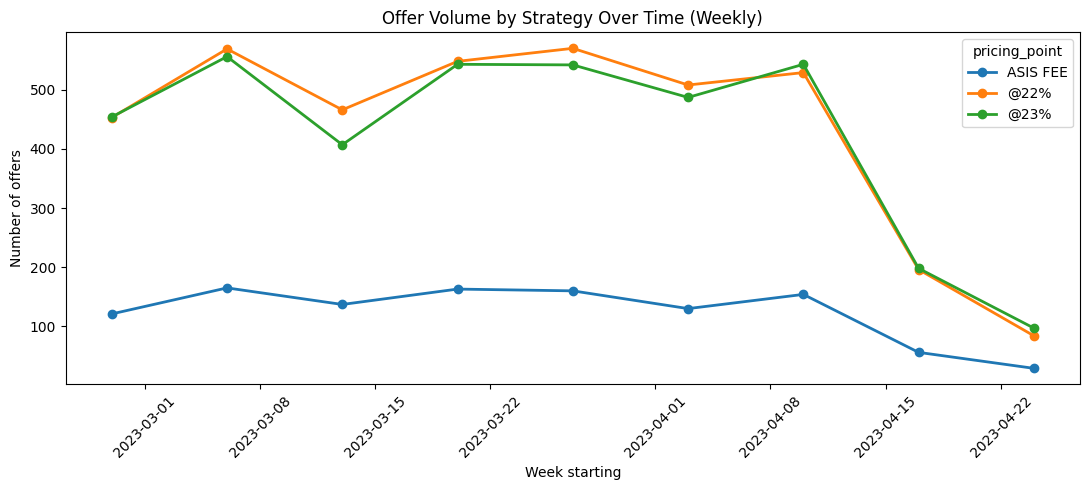

In [30]:
strategy_order = ["ASIS FEE", "@22%", "@23%"]

offers_by_week = (
    df_analysis
    .assign(offer_week=df_analysis["offerdate"].dt.to_period("W").dt.start_time)
    .groupby(["offer_week", "pricing_point"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=strategy_order)
)

colors = {"ASIS FEE": "tab:blue", "@22%": "tab:orange", "@23%": "tab:green"}

fig, ax = plt.subplots(figsize=(11, 5))

for strategy in strategy_order:
    ax.plot(
        offers_by_week.index,
        offers_by_week[strategy],
        marker="o",
        linewidth=2,
        color=colors[strategy],
        label=strategy
    )

ax.set_title("Offer Volume by Strategy Over Time (Weekly)")
ax.set_ylabel("Number of offers")
ax.set_xlabel("Week starting")
ax.legend(title="pricing_point")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "offer_volume_by_strategyovertime_weekly.png", dpi=200, bbox_inches="tight")
plt.show()

2. Price variation by strategy

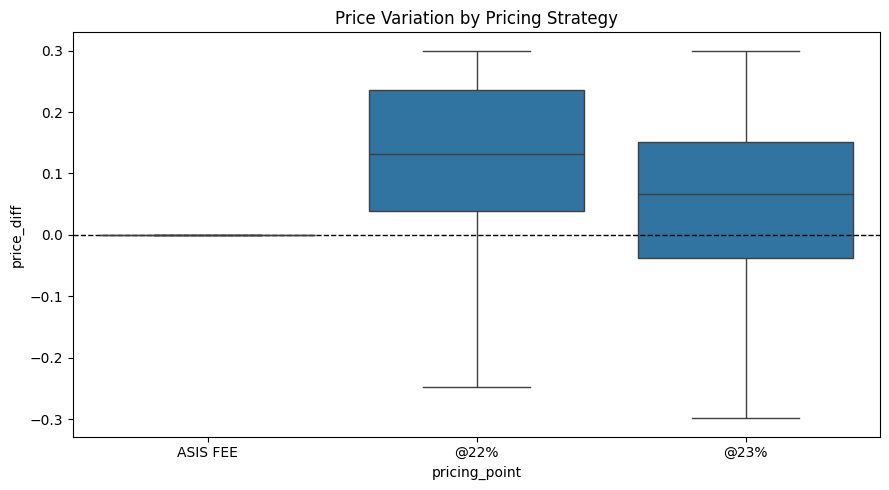

base_rate                   offered_premium                    \
                    mean median        std            mean median        std   
pricing_point                                                                  
ASIS FEE       48.973668  45.12  13.662768       48.973668  45.12  13.662768   
@22%           49.200958  45.96  13.568544       55.212603  48.24  16.599861   
@23%           49.014236  45.96  13.533731       51.976650  48.12  16.305909   

              price_diff                      
                    mean    median       std  
pricing_point                                 
ASIS FEE        0.000000  0.000000  0.000000  
@22%            0.124322  0.131148  0.130160  
@23%            0.059686  0.066489  0.131832

In [29]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_analysis, x="pricing_point", y="price_diff",
    order=strategy_order, showfliers=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Price Variation by Pricing Strategy")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_variation_by_strategy.png", dpi=200, bbox_inches="tight")
plt.show()

price_stats = (
    df_analysis
    .groupby("pricing_point")[["base_rate", "offered_premium", "price_diff"]]
    .agg(["mean", "median", "std"])
    .reindex(strategy_order)
)
display(price_stats)

3. Conversion vs price movement

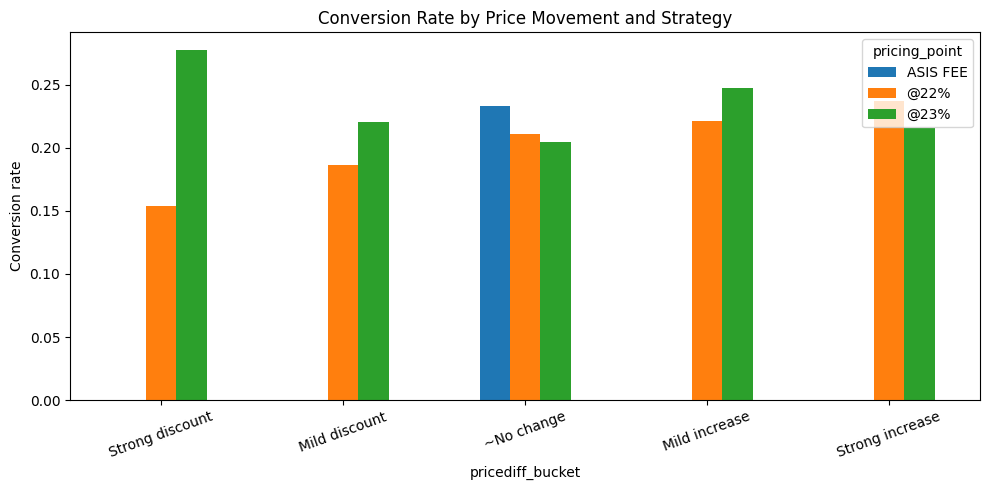

In [31]:
df_analysis["pricediff_bucket"] = pd.cut(
    df_analysis["price_diff"],
    bins=[-1, -0.2, -0.05, 0.05, 0.2, 1],
    labels=["Strong discount", "Mild discount", "~No change", "Mild increase", "Strong increase"]
)

conversion_by_bucket = (
    df_analysis
    .groupby(["pricing_point", "pricediff_bucket"], observed=True)["sale_flag"]
    .mean()
    .unstack()
    .reindex(strategy_order)
)

conversion_by_bucket.T.plot(kind="bar", figsize=(10, 5))
plt.title("Conversion Rate by Price Movement and Strategy")
plt.ylabel("Conversion rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "conversion_rate_by_price_movement_and_strategy.png", dpi=200, bbox_inches="tight")
plt.show()

4. Predicted vs actual conversion (model calibration)

In [20]:
calibration = (
    df_analysis
    .groupby("pricing_point")
    .agg(
        avg_predicted_conversion=("predictedconversionrate", "mean"),
        actual_conversion=("sale_flag", "mean"),
        n=("sale_flag", "size")
    )
    .reindex(strategy_order)
)

calibration["gap"] = calibration["actual_conversion"] - calibration["avg_predicted_conversion"]
display(calibration)

,avg_predicted_conversion,actual_conversion,n,gap
pricing_point,,,,
ASIS FEE,1.000000,0.233184,1115,-0.766816
@22%,0.212373,0.220240,3923,0.007866
@23%,0.222569,0.226548,3827,0.003980


In [27]:
df_analysis[df_analysis["pricing_point"] == "ASIS FEE"]["predictedconversionrate"].value_counts(dropna=False).head(10)

predictedconversionrate
1.0    1115
Name: count, dtype: int64

5. Customer profile comparability

In [21]:
customer_profile = (
    df_analysis
    .groupby("pricing_point")
    .agg(
        pct_has_plan=("plan_flag", lambda x: (x == "1").mean() if x.dtype == object else x.mean()),
        avg_plancount=("plan_count", "mean"),
        avg_plans_active_lastyear=("plansactive_lastyear_count", "mean"),
        avg_plans_cancelled_lastyear=("planscancelled_lastyear_count", "mean")
    )
    .reindex(strategy_order)
)

display(customer_profile)

,pct_has_plan,avg_plancount,avg_plans_active_lastyear,avg_plans_cancelled_lastyear
pricing_point,,,,
ASIS FEE,0.198206,0.421622,0.676577,0.221622
@22%,0.195769,0.406402,0.649168,0.201024
@23%,0.198328,0.408769,0.721974,0.269100


6. Appliance profile comparability

In [23]:
appliance_profile = (
    df_analysis
    .groupby("pricing_point")
    .agg(
        avg_purchase_price=("purchase_price", "mean"),
        median_item_age_days=("item_age", "median"),
        n_manufacturers=("manufacturerbrandname_enc", "nunique"),
        n_categories=("itemcategoryname_enc", "nunique")
    )
    .reindex(strategy_order)
)

display(appliance_profile)

top_categories = (
    df_analysis
    .groupby(["pricing_point", "itemcategoryname_enc"], observed=True)
    .size()
    .groupby("pricing_point", group_keys=False)
    .apply(lambda x: x.sort_values(ascending=False).head(5))
)
display(top_categories)

,avg_purchase_price,median_item_age_days,n_manufacturers,n_categories
pricing_point,,,,
ASIS FEE,397.633058,7.0,57,22
@22%,404.746323,7.0,80,24
@23%,411.354335,7.0,75,24


pricing_point  itemcategoryname_enc
@22%           37                      910
               16                      472
               25                      359
               11                      336
               19                      286
@23%           37                      834
               16                      429
               25                      387
               11                      356
               12                      283
ASIS FEE       37                      267
               25                      117
               11                      111
               16                       99
               19                       86
dtype: int64

7. Claims exploration

In [24]:
claims_summary = (
    df_analysis
    .groupby("pricing_point")
    .agg(
        pct_with_claims=("claims_count", lambda x: (x.fillna(0) > 0).mean()),
        avg_claim_amount=("claim_amount", "mean"),
        avg_claim_count=("claims_count", "mean")
    )
    .reindex(strategy_order)
)
display(claims_summary)

conversion_by_claims = (
    df_analysis
    .assign(has_claim=lambda x: x["claims_count"].fillna(0) > 0)
    .groupby("has_claim")["sale_flag"]
    .mean()
)
display(conversion_by_claims)

,pct_with_claims,avg_claim_amount,avg_claim_count
pricing_point,,,
ASIS FEE,0.097758,25.013102,0.203723
@22%,0.087943,28.190387,0.203493
@23%,0.087275,31.564517,0.220881


has_claim
False    0.199579
True     0.480964
Name: sale_flag, dtype: float64

8. Correlation and distribution checks

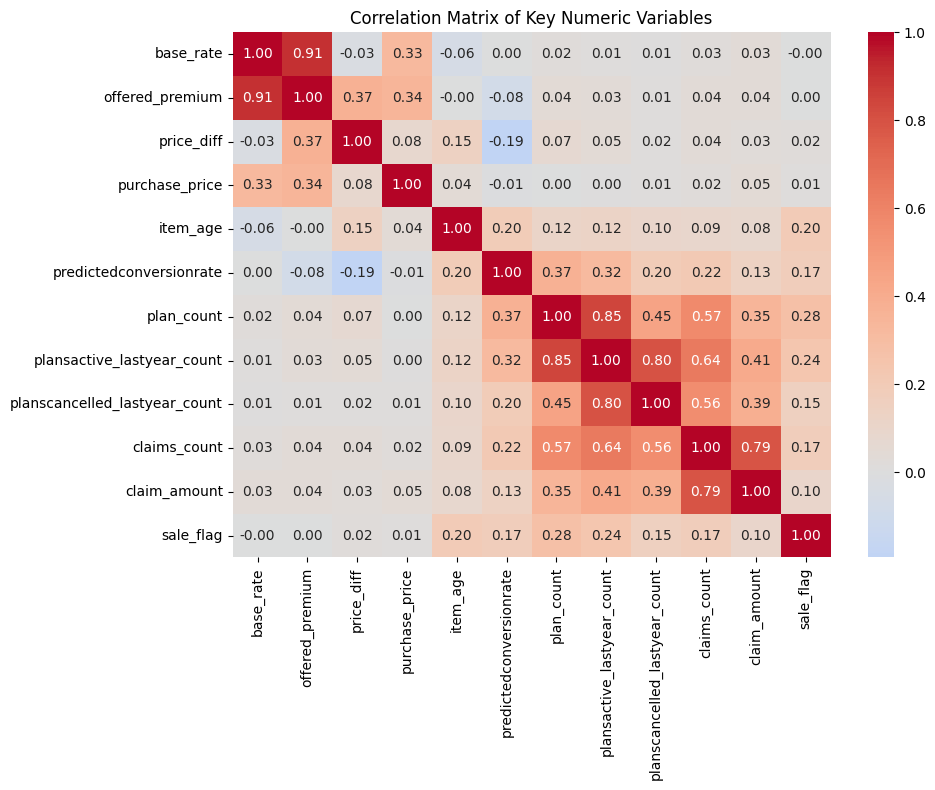

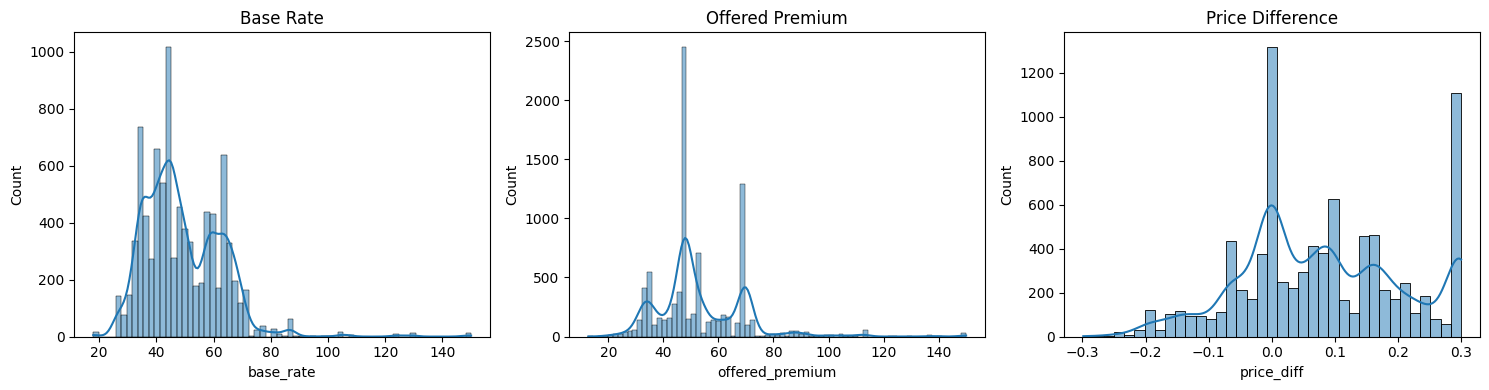

In [32]:
numeric_cols = [
    "base_rate", "offered_premium", "price_diff", "purchase_price",
    "item_age", "predictedconversionrate", "plan_count",
    "plansactive_lastyear_count", "planscancelled_lastyear_count",
    "claims_count", "claim_amount", "sale_flag"
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_analysis[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_analysis["base_rate"], kde=True, ax=axes[0]).set_title("Base Rate")
sns.histplot(df_analysis["offered_premium"], kde=True, ax=axes[1]).set_title("Offered Premium")
sns.histplot(df_analysis["price_diff"], kde=True, ax=axes[2]).set_title("Price Difference")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_point_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

9. Revenue Realisation

In [26]:
df_analysis["realised_uplift"] = np.where(
    df_analysis["sale_flag"] == 1,
    df_analysis["sold_premium"] - df_analysis["base_rate"],
    np.nan
)

revenue_realisation = (
    df_analysis
    .groupby("pricing_point")
    .agg(
        avg_realised_uplift=("realised_uplift", "mean"),
        total_realised_uplift=("realised_uplift", "sum")
    )
    .reindex(strategy_order)
)
display(revenue_realisation)

,avg_realised_uplift,total_realised_uplift
pricing_point,,
ASIS FEE,0.000000,0.00
@22%,6.417917,5545.08
@23%,2.923599,2534.76


In [33]:
price_stats.to_csv(TABLES_DIR / "price_stats_by_strategy.csv")
calibration.to_csv(TABLES_DIR / "calibration_by_strategy.csv")
claims_summary.to_csv(TABLES_DIR / "claims_summary_by_strategy.csv")
appliance_profile.to_csv(TABLES_DIR / "appliance_profile_by_strategy.csv")
customer_profile.to_csv(TABLES_DIR / "customer_profile_by_strategy.csv")
revenue_realisation.to_csv(TABLES_DIR / "revenue_realisation_by_strategy.csv")